# Does the Median Voter Theorem work for higher dimensions than 1?

This notebook looks at a simple question about the median voter theorem. On a line, with two candidates and majority rule a candidate at the voter median cannot be beaten in a head-to-head contest.

The goal here is to see how much of that idea generalizes to multiple dimensions. The notebook starts in `1D`, where the classical theorem works exactly as expected, and then moves to `2D`, `3D`, `5D`, and `10D` to see what still behaves in a median-like way and what starts to break.

The comparison uses three notions of political center throughout:

- the mean,
- the componentwise median,
- the geometric median.


---
## Imports and configuration

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
if (cwd / "configs").exists() and (cwd / "electoral_sim").exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from electoral_sim.ballots import BallotProfile
from electoral_sim.candidates import fixed_candidates
from electoral_sim.electorate import gaussian_mixture_electorate
from electoral_sim.social_choice import pairwise_summary
from electoral_sim.utils import (
    compute_electorate_centers,
    pairwise_majority_vote,
    plot_electorate,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

DIMENSIONS = [1, 2, 3, 5, 10]
CENTER_LABELS = ["Mean", "Componentwise median", "Geometric median"]

---
## Preliminary refresher: what the theorem says

On a line, each voter has an ideal point and prefers candidates closer to that point. If there are two candidates and the election is decided by majority rule, the voter median becomes the key pivot.


A natural next question is whether some broader idea of the center still helps. This notebook looks at three candidates for that role:

- the mean, which averages voter positions,
- the componentwise median, which takes a median on each axis separately,
- the geometric median, which minimizes total Euclidean distance to the electorate.


---
## Electorates and cases

The notebook uses three kinds of examples:

- A **one-dimensional skewed electorate** to show the theorem working exactly as expected.
- A **majority-cycle case** that appears once politics stops being just a line.
- A **dimension sweep** from `1` to `10` dimensions, where each center point is tested against many directional challengers.

The dimension sweep is not meant to be a formal theorem. It is a practical stress test. If a center point is supposed to play a role similar to the 1D median, how often does it actually survive head-to-head majority contests as the geometry gets richer?


---
## Helper functions

The next cell defines the electorates and comparison helpers used throughout the notebook.

In [2]:
def make_one_dim_electorate(seed, n_voters=4001):
    rng = np.random.default_rng(seed)
    return gaussian_mixture_electorate(
        n_voters,
        [
            {"weight": 0.56, "mean": [0.24], "cov": [[0.006]]},
            {"weight": 0.24, "mean": [0.52], "cov": [[0.008]]},
            {"weight": 0.20, "mean": [0.82], "cov": [[0.006]]},
        ],
        rng=rng,
        dim_names=["left-right"],
    )


# The higher-dimensional family keeps one low-leaning bloc and two cross-pressured blocs.
# On a line this still behaves like ordinary single-peaked politics.
# In higher dimensions the same family becomes harder to summarize with a single pivot voter.
def make_dimensional_electorate(n_dims, seed, n_voters=4001):
    rng = np.random.default_rng(seed)
    anchor = np.full(n_dims, 0.32)
    cross_a = np.array([0.80 if i % 2 == 0 else 0.25 for i in range(n_dims)], dtype=float)
    cross_b = np.array([0.25 if i % 2 == 0 else 0.80 for i in range(n_dims)], dtype=float)
    var = 0.010 if n_dims <= 3 else 0.008
    cov = (np.eye(n_dims) * var).tolist()
    return gaussian_mixture_electorate(
        n_voters,
        [
            {"weight": 0.44, "mean": anchor.tolist(), "cov": cov},
            {"weight": 0.31, "mean": cross_a.tolist(), "cov": cov},
            {"weight": 0.25, "mean": cross_b.tolist(), "cov": cov},
        ],
        rng=rng,
        dim_names=[f"dim_{i + 1}" for i in range(n_dims)],
    )


def make_majority_cycle_case(n_dims, seed, n_voters=3000):
    if n_dims < 2:
        raise ValueError("The majority-cycle case needs at least 2 dimensions.")

    rng = np.random.default_rng(seed)

    def pad(base):
        if n_dims == 2:
            return np.array(base, dtype=float)
        return np.concatenate([np.array(base, dtype=float), np.full(n_dims - 2, 0.50)])

    candidates = fixed_candidates(
        [pad([0.20, 0.20]), pad([0.80, 0.20]), pad([0.50, 0.80])],
        ["A", "B", "C"],
    )

    base_cov = np.eye(n_dims) * 0.006
    electorate = gaussian_mixture_electorate(
        n_voters,
        [
            {"weight": 1 / 3, "mean": pad([0.40, 0.25]).tolist(), "cov": base_cov.tolist()},
            {"weight": 1 / 3, "mean": pad([0.65, 0.45]).tolist(), "cov": base_cov.tolist()},
            {"weight": 1 / 3, "mean": pad([0.40, 0.55]).tolist(), "cov": base_cov.tolist()},
        ],
        rng=rng,
        dim_names=[f"dim_{i + 1}" for i in range(n_dims)],
    )
    return electorate, candidates


def directional_challengers(center_point, n_samples, rng, radius=0.32):
    challengers = []
    n_dims = len(center_point)
    for _ in range(n_samples):
        direction = rng.normal(size=n_dims)
        norm = np.linalg.norm(direction)
        if norm < 1e-12:
            continue
        direction = direction / norm
        challengers.append(np.clip(center_point + radius * direction, 0.0, 1.0))
    return np.array(challengers)


def plot_one_dim_electorate(electorate, centers, ax, title):
    x = electorate.preferences[:, 0]
    ax.hist(x, bins=50, color="#c9d7f8", edgecolor="white")
    colors = {
        "Mean": "#d1495b",
        "Componentwise median": "#2a9d8f",
        "Geometric median": "#264653",
    }
    for label in CENTER_LABELS:
        xpos = centers[label][0]
        ax.axvline(xpos, color=colors[label], linestyle="--", linewidth=2, label=label)
    ax.set_xlim(0, 1)
    ax.set_xlabel("left-right position")
    ax.set_ylabel("voters")
    ax.set_title(title)
    ax.legend(fontsize=8)


def sweep_one_dim_contests(electorate, centers, challenger_grid):
    rows = []
    for label, point in centers.items():
        for challenger_position in challenger_grid:
            if abs(challenger_position - point[0]) < 1e-9:
                continue
            result = pairwise_majority_vote(
                electorate,
                np.array([[point[0]], [challenger_position]], dtype=float),
                candidate_labels=(label, "Challenger"),
            )
            rows.append(
                {
                    "center_label": label,
                    "challenger_position": challenger_position,
                    "center_vote_share": result.vote_shares[0],
                    "margin": result.margin,
                }
            )
    return pd.DataFrame(rows)


def evaluate_center_candidates(electorate, n_samples=400, search_samples=4000, seed=0):
    centers = compute_electorate_centers(electorate)
    center_points = {
        "Mean": centers.mean,
        "Componentwise median": centers.componentwise_median,
        "Geometric median": centers.geometric_median,
    }

    rows = []
    hardest_examples = {}
    for idx, (label, point) in enumerate(center_points.items()):
        rng = np.random.default_rng(seed + idx)
        challengers = directional_challengers(point, search_samples, rng)
        margins = []
        for challenger in challengers:
            result = pairwise_majority_vote(
                electorate,
                np.vstack([point, challenger]),
                candidate_labels=(label, "Challenger"),
            )
            margins.append(result.margin)
        margins = np.asarray(margins, dtype=float)
        worst_idx = int(margins.argmin())
        hardest_examples[label] = {
            "center_point": point.copy(),
            "challenger": challengers[worst_idx].copy(),
            "worst_margin": float(margins[worst_idx]),
        }
        rows.append(
            {
                "center_label": label,
                "win_rate": float((margins[:n_samples] >= 0).mean()),
                "mean_margin": float(margins[:n_samples].mean()),
                "worst_margin": float(margins.min()),
                "undefeated_in_search": bool((margins >= 0).all()),
            }
        )

    return pd.DataFrame(rows), hardest_examples, center_points


def make_center_candidates(center_points):
    return fixed_candidates(
        [center_points["Mean"], center_points["Componentwise median"], center_points["Geometric median"]],
        ["Mean", "Component median", "Geometric median"],
    )

---
## Example layouts in 2D and 5D

Before looking at results, it helps to see the kind of electorate used in the dimension sweep. In two dimensions the geometry is still easy to see directly. In five dimensions the plot is only a PCA view of the full space, which is already a reminder that the simple 1D picture no longer tells the whole story.


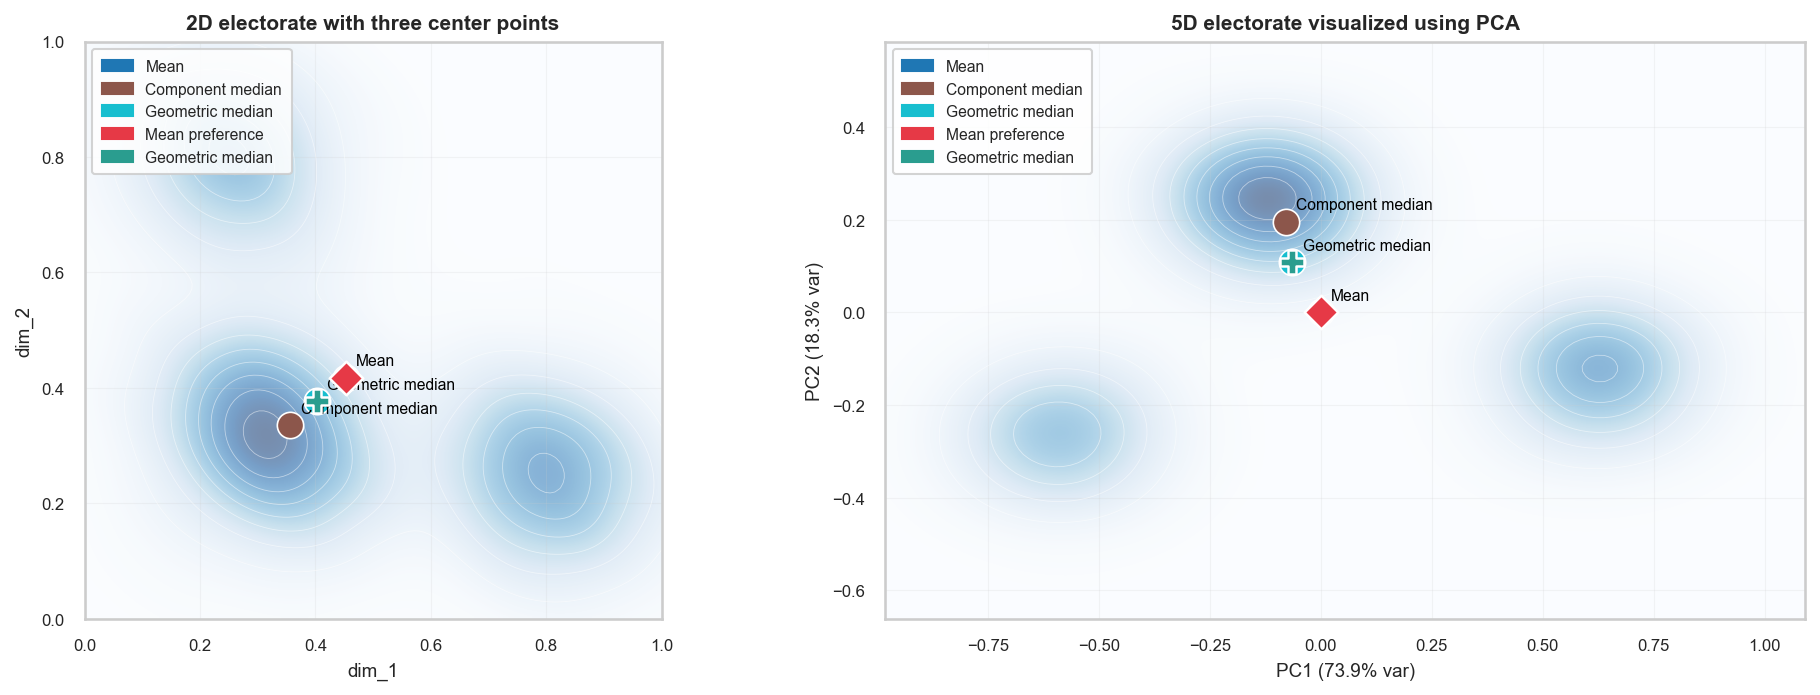

In [11]:
preview_2d = make_dimensional_electorate(2, seed=102)
preview_5d = make_dimensional_electorate(5, seed=105)
preview_2d_centers = make_center_candidates(
    {
        "Mean": compute_electorate_centers(preview_2d).mean,
        "Componentwise median": compute_electorate_centers(preview_2d).componentwise_median,
        "Geometric median": compute_electorate_centers(preview_2d).geometric_median,
    }
)
preview_5d_centers = make_center_candidates(
    {
        "Mean": compute_electorate_centers(preview_5d).mean,
        "Componentwise median": compute_electorate_centers(preview_5d).componentwise_median,
        "Geometric median": compute_electorate_centers(preview_5d).geometric_median,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=150)
plot_electorate(preview_2d, preview_2d_centers, title="2D electorate with three center points", ax=axes[0])
plot_electorate(preview_5d, preview_5d_centers, title="5D electorate visualized using PCA", ax=axes[1])
fig.tight_layout()

---
## A one-dimensional case where the theorem works exactly

The first figure uses a one-dimensional electorate with a visible skew, so the mean and the median do not sit at the same place.

The second figure moves a challenger across the line and asks how much of the vote each center point gets in a head-to-head majority contest. If the theorem is showing up clearly, the median-based candidates should never drop below `50%`.


,center_label,center_position,minimum_vote_share,worst_challenger_position
0,Mean,0.415,0.407,0.412
1,Componentwise median,0.320,0.501,0.322
2,Geometric median,0.320,0.501,0.322


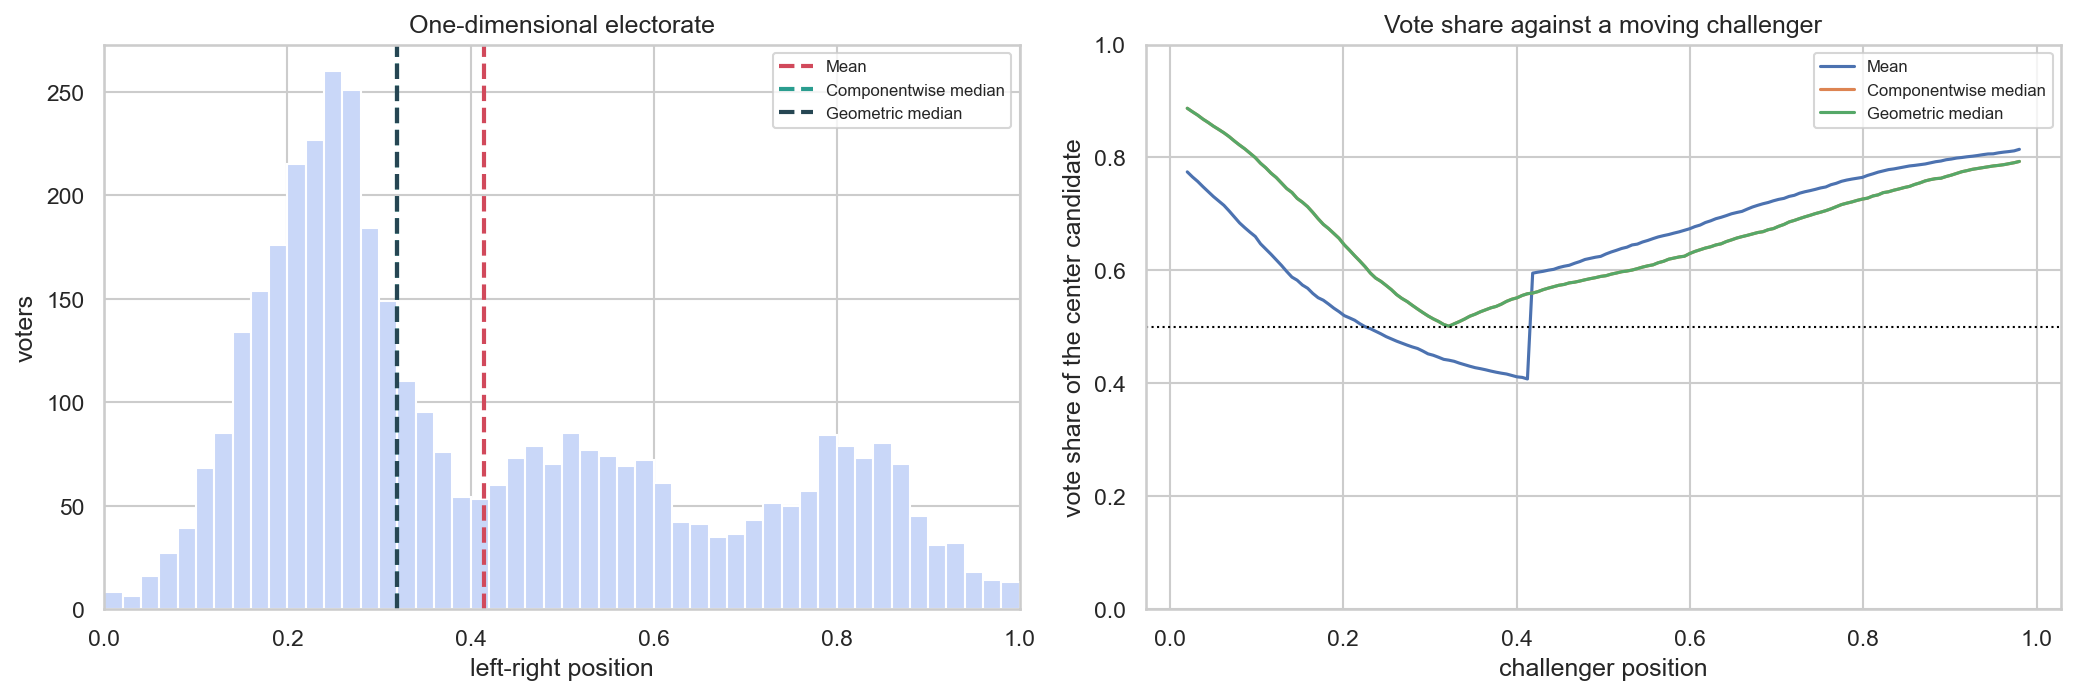

In [4]:
one_dim_electorate = make_one_dim_electorate(seed=42)
one_dim_centers_raw = compute_electorate_centers(one_dim_electorate)
one_dim_centers = {
    "Mean": one_dim_centers_raw.mean,
    "Componentwise median": one_dim_centers_raw.componentwise_median,
    "Geometric median": one_dim_centers_raw.geometric_median,
}
challenger_grid = np.linspace(0.02, 0.98, 160)
one_dim_sweep = sweep_one_dim_contests(one_dim_electorate, one_dim_centers, challenger_grid)

summary_rows = []
for label in CENTER_LABELS:
    subset = one_dim_sweep[one_dim_sweep["center_label"] == label]
    worst_idx = subset["center_vote_share"].idxmin()
    summary_rows.append(
        {
            "center_label": label,
            "center_position": float(one_dim_centers[label][0]),
            "minimum_vote_share": float(subset.loc[worst_idx, "center_vote_share"]),
            "worst_challenger_position": float(subset.loc[worst_idx, "challenger_position"]),
        }
    )
one_dim_summary = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), dpi=150)
plot_one_dim_electorate(one_dim_electorate, one_dim_centers, axes[0], "One-dimensional electorate")
sns.lineplot(
    data=one_dim_sweep,
    x="challenger_position",
    y="center_vote_share",
    hue="center_label",
    ax=axes[1],
)
axes[1].axhline(0.5, color="black", linestyle=":", linewidth=1)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("Vote share against a moving challenger")
axes[1].set_xlabel("challenger position")
axes[1].set_ylabel("vote share of the center candidate")
axes[1].legend(fontsize=8)
fig.tight_layout()

display(one_dim_summary)

The theorem shows up clearly in this example.

- The componentwise median and the geometric median are basically the same in one dimension.
- Neither of them ever drops below a majority.
- The mean does not enjoy the same guarantee. In this skewed case it can be beaten.

So even on a line, it matters that the theorem talks about a median voter, not just any center-like average.


---
## A majority cycle appears once the geometry stops being a line

The next case uses three candidates and three voter blocs arranged so that pairwise majority rule runs in a circle:

- `A` beats `B`,
- `B` beats `C`,
- `C` beats `A`.

This is the key break. Once politics is no longer just a line, majority rule can lose its single pivot. There may be no Condorcet winner at all.


,dimension,condorcet_winner,majority_cycle
0,2,None,A > B > C > A
1,3,None,A > B > C > A
2,5,None,A > B > C > A
3,10,None,A > B > C > A


,A,B,C
A,0.000,0.230,-0.106
B,-0.230,0.000,0.105
C,0.106,-0.105,0.000


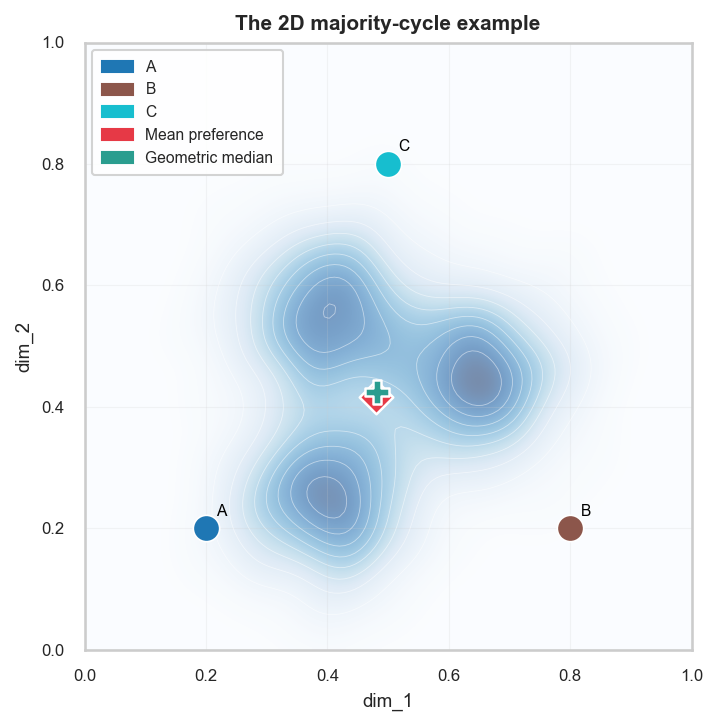

In [5]:
cycle_rows = []
cycle_margin_table = None
cycle_2d = None
for dim in [2, 3, 5, 10]:
    electorate, candidates = make_majority_cycle_case(dim, seed=200 + dim)
    ballots = BallotProfile.from_preferences(electorate, candidates)
    summary = pairwise_summary(ballots, candidates)
    condorcet_label = None if summary.condorcet_winner is None else summary.labels[summary.condorcet_winner]
    cycle_labels = None
    if summary.majority_cycle is not None:
        cycle_labels = " > ".join(summary.labels[idx] for idx in summary.majority_cycle)
    cycle_rows.append(
        {
            "dimension": dim,
            "condorcet_winner": condorcet_label,
            "majority_cycle": cycle_labels,
        }
    )
    if dim == 2:
        cycle_2d = (electorate, candidates)
        cycle_margin_table = pd.DataFrame(
            summary.margin_matrix,
            index=summary.labels,
            columns=summary.labels,
        )

cycle_frame = pd.DataFrame(cycle_rows)
display(cycle_frame)
display(cycle_margin_table)

fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
plot_electorate(cycle_2d[0], cycle_2d[1], title="The 2D majority-cycle example", ax=ax)
fig.tight_layout()

---
## Run the dimension sweep

The final experiment goes back to head-to-head majority contests, but now it asks a weaker and more practical question. If a candidate is placed at a plausible center point, how often does that candidate survive against many directional challengers as the number of dimensions grows?

This is not a full characterization of higher-dimensional majority rule. It is a stress test of the median-voter intuition.


In [6]:
all_rows = []
hardest_examples = {}
center_points_by_dim = {}
for dim in DIMENSIONS:
    electorate = make_dimensional_electorate(dim, seed=300 + dim)
    summary_frame, hardest, center_points = evaluate_center_candidates(
        electorate,
        n_samples=400,
        search_samples=4000,
        seed=600 + dim,
    )
    summary_frame["dimension"] = dim
    all_rows.append(summary_frame)
    hardest_examples[dim] = {"electorate": electorate, "hardest": hardest}
    center_points_by_dim[dim] = center_points

results = pd.concat(all_rows, ignore_index=True)
results = results[[
    "dimension",
    "center_label",
    "win_rate",
    "mean_margin",
    "worst_margin",
    "undefeated_in_search",
]]
results.head(9)

,dimension,center_label,win_rate,mean_margin,worst_margin,undefeated_in_search
0,1,Mean,1.000,0.358,0.325,True
1,1,Componentwise median,1.000,0.570,0.352,True
2,1,Geometric median,1.000,0.556,0.352,True
3,2,Mean,1.000,0.449,0.282,True
4,2,Componentwise median,1.000,0.510,0.063,True
5,2,Geometric median,1.000,0.497,0.281,True
6,3,Mean,1.000,0.473,0.020,True
7,3,Componentwise median,0.993,0.551,-0.042,False
8,3,Geometric median,1.000,0.522,0.144,True


---
## How often does each center point survive?

The first heatmap shows the share of sampled challengers that the center point defeated or tied. The second shows the worst margin found in the larger directional search. Positive numbers mean the center point still won its toughest observed contest. Negative numbers mean a challenger beat it.


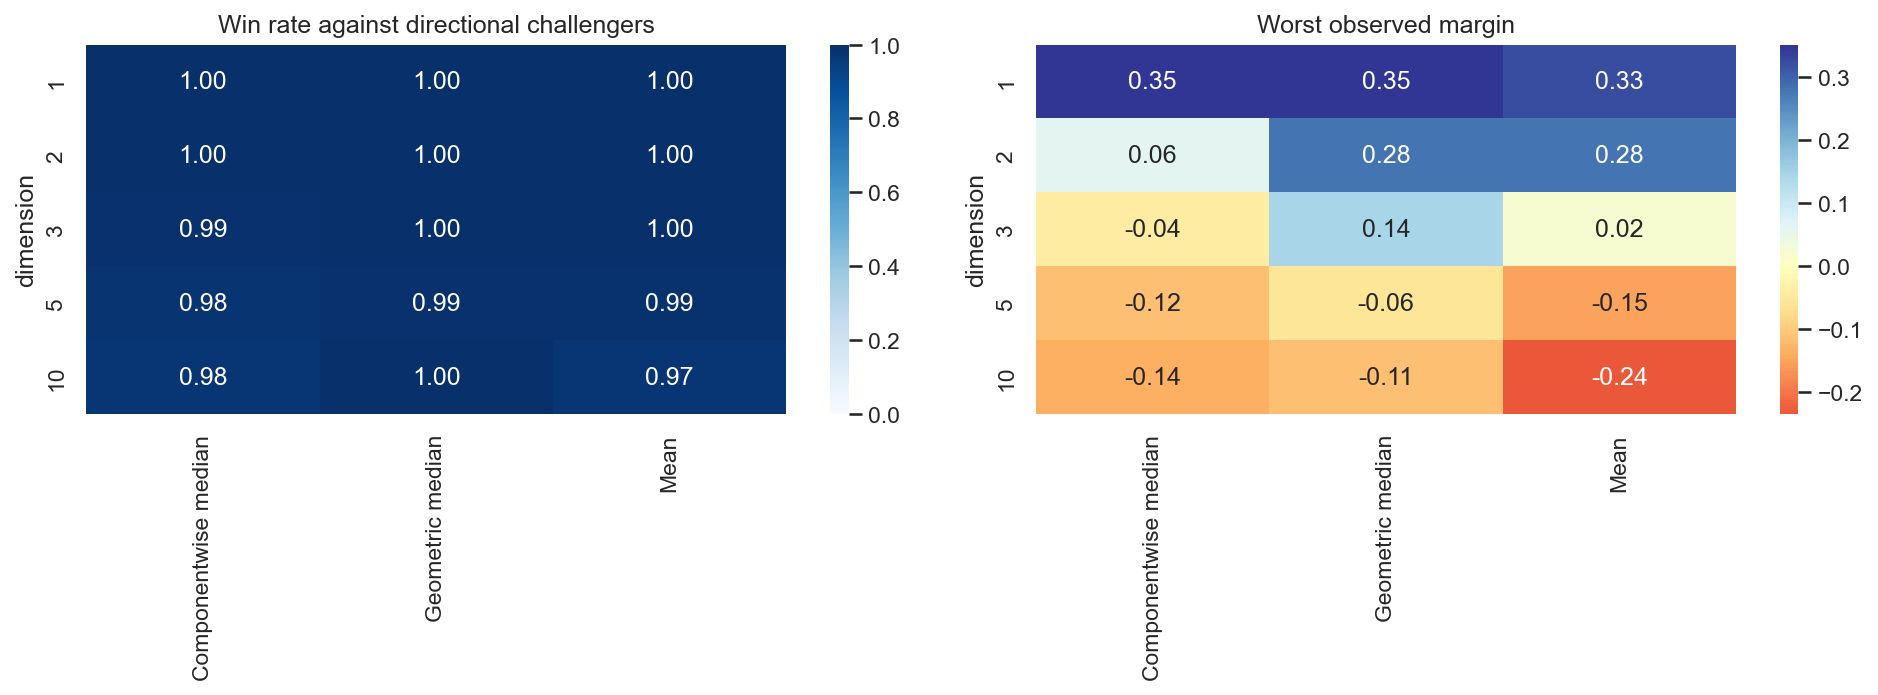

In [7]:
win_rate_pivot = results.pivot(index="dimension", columns="center_label", values="win_rate")
worst_margin_pivot = results.pivot(index="dimension", columns="center_label", values="worst_margin")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=150)
sns.heatmap(win_rate_pivot, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Win rate against directional challengers")
axes[0].set_xlabel("")
axes[0].set_ylabel("dimension")

sns.heatmap(worst_margin_pivot, annot=True, fmt=".2f", cmap="RdYlBu", center=0, ax=axes[1])
axes[1].set_title("Worst observed margin")
axes[1].set_xlabel("")
axes[1].set_ylabel("dimension")
fig.tight_layout()

The line plots below show the same pattern in a slightly different way.

- In one dimension, the median-based candidates are unbeaten in this search.
- As dimensions grow, all three notions of center become rougher approximations.
- The geometric median usually holds up best, but it is no longer guaranteed to be unbeatable.


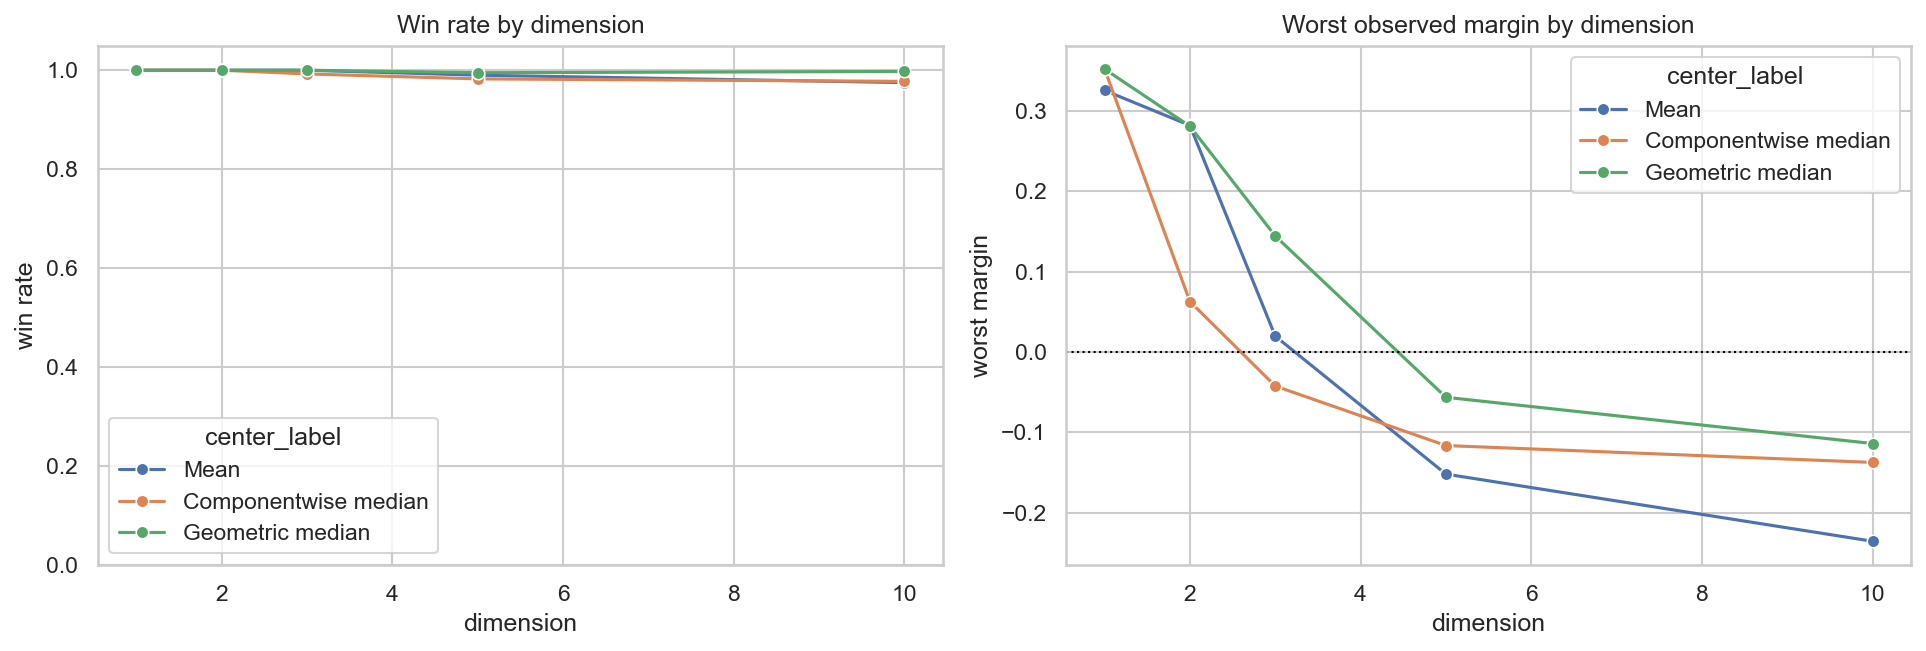

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)
sns.lineplot(data=results, x="dimension", y="win_rate", hue="center_label", marker="o", ax=axes[0])
axes[0].set_ylim(0.0, 1.05)
axes[0].set_title("Win rate by dimension")
axes[0].set_ylabel("win rate")

sns.lineplot(data=results, x="dimension", y="worst_margin", hue="center_label", marker="o", ax=axes[1])
axes[1].axhline(0.0, color="black", linestyle=":", linewidth=1)
axes[1].set_title("Worst observed margin by dimension")
axes[1].set_ylabel("worst margin")
fig.tight_layout()

---
## Compact table

This table collects the main results in one place.


In [10]:
compact_table = results.copy()
compact_table["undefeated_in_search"] = compact_table["undefeated_in_search"].map({True: "Yes", False: "No"})
compact_table.sort_values(["dimension", "center_label"]).reset_index(drop=True)

,dimension,center_label,win_rate,mean_margin,worst_margin,undefeated_in_search
0,1,Componentwise median,1.000,0.570,0.352,Yes
1,1,Geometric median,1.000,0.556,0.352,Yes
2,1,Mean,1.000,0.358,0.325,Yes
3,2,Componentwise median,1.000,0.510,0.063,Yes
4,2,Geometric median,1.000,0.497,0.281,Yes
5,2,Mean,1.000,0.449,0.282,Yes
6,3,Componentwise median,0.993,0.551,-0.042,No
7,3,Geometric median,1.000,0.522,0.144,Yes
8,3,Mean,1.000,0.473,0.020,Yes
9,5,Componentwise median,0.983,0.595,-0.116,No


---
## Takeaways

A few patterns stand out.

- In one dimension, the median-based candidate survives every head-to-head contest in the sweep.
- The mean is not the same thing as the median. Even on a line, it can lose where the median does not.
- Once politics is no longer just a line, majority rule can lose its single pivot entirely. 
- In the dimension sweep, the geometric median is usually the strongest higher-dimensional center. It tends to beat more challengers, and its worst losses are usually smaller.
- But none of the higher-dimensional center points comes with the exact 1D guarantee. By five or ten dimensions, even the geometric median can be beaten by some well-placed challenger.

So the median voter theorem does not really generalize as a theorem once the geometry becomes multidimensional. However, multidimensional equivalents of median generally tend to perform quite well, even if they are no longer undefeatable. In practical terms, this can be interpreted as the reason why politicians like to appease the median voter. It's because the closer they are to the median voter, the more likely they are to win. It is however important to remember that one has to be close to the median likely voter from ones jurisdiction and assume they don't partake in strategic voting. 

Original paper: Black, D. (1948). On the Rationale of Group Decision-making. Journal of Political Economy, 56(1), 23-34.
